[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lweber89/geocrime-stl/blob/main/notebooks/demo.ipynb)

In [ ]:
# Uncomment the line below to install the package if running in Google Colab
# %pip install geocrime-stl -q

In [1]:
import os
import geocrime_stl as gc

### Run the ETL pipeline (using April 2026 data as a test case)

In [2]:
data_pkg = gc.run_pipeline(4, 2026)

### Verify the raw CSV came through the ETL pipeline and was delivered as a CrimeDataPackage

In [3]:
print(f"Package Type: {type(data_pkg)}")
print(f"Package Tags: Month={data_pkg.month}, Year={data_pkg.year}")
print(f"Data Shape:   {data_pkg.df.shape}")

Package Type: <class 'geocrime_stl.etl.transform.CrimeDataPackage'>
Package Tags: Month=4, Year=2026
Data Shape:   (3753, 14)


### Output Summary Statistics of the Monthly Data

In [4]:
gc.generate_monthly_metrics(data_pkg)

📊 ST. LOUIS CRIME DATA SUMMARY REPORT
📅 April 2026
🔹 Total Incident Count: 3753

🚨 TOP 5 CRIME CATEGORIES:
  - Weapons Law Violations: 520 incidents
  - Destruction/Damage/Vandalism of Property: 472 incidents
  - Motor Vehicle Theft: 262 incidents
  - Theft From Motor Vehicle: 255 incidents
  - Simple Assault: 253 incidents

⭐ INCIDENTS BY POLICE DISTRICT:
  - District 1: 627 incidents
  - District 2: 578 incidents
  - District 3: 555 incidents
  - District 4: 805 incidents
  - District 5: 616 incidents
  - District 6: 571 incidents

🔫 FIREARM INVOLVEMENT:
  - Firearm Involved: 722 (19.2%)

🏘️ NEIGHBORHOOD SUMMARY:

Offense Type: Person
------------------------------
  * Downtown: 34 incidents
  * Downtown West: 33 incidents
  * Dutchtown: 32 incidents

Offense Type: Property
------------------------------
  * Dutchtown: 83 incidents
  * Downtown: 78 incidents
  * Carondelet: 71 incidents

Offense Type: Society
------------------------------
  * Dutchtown: 61 incidents
  * Downtown: 56

### Output Crime Distribution Maps of the Monthly Data

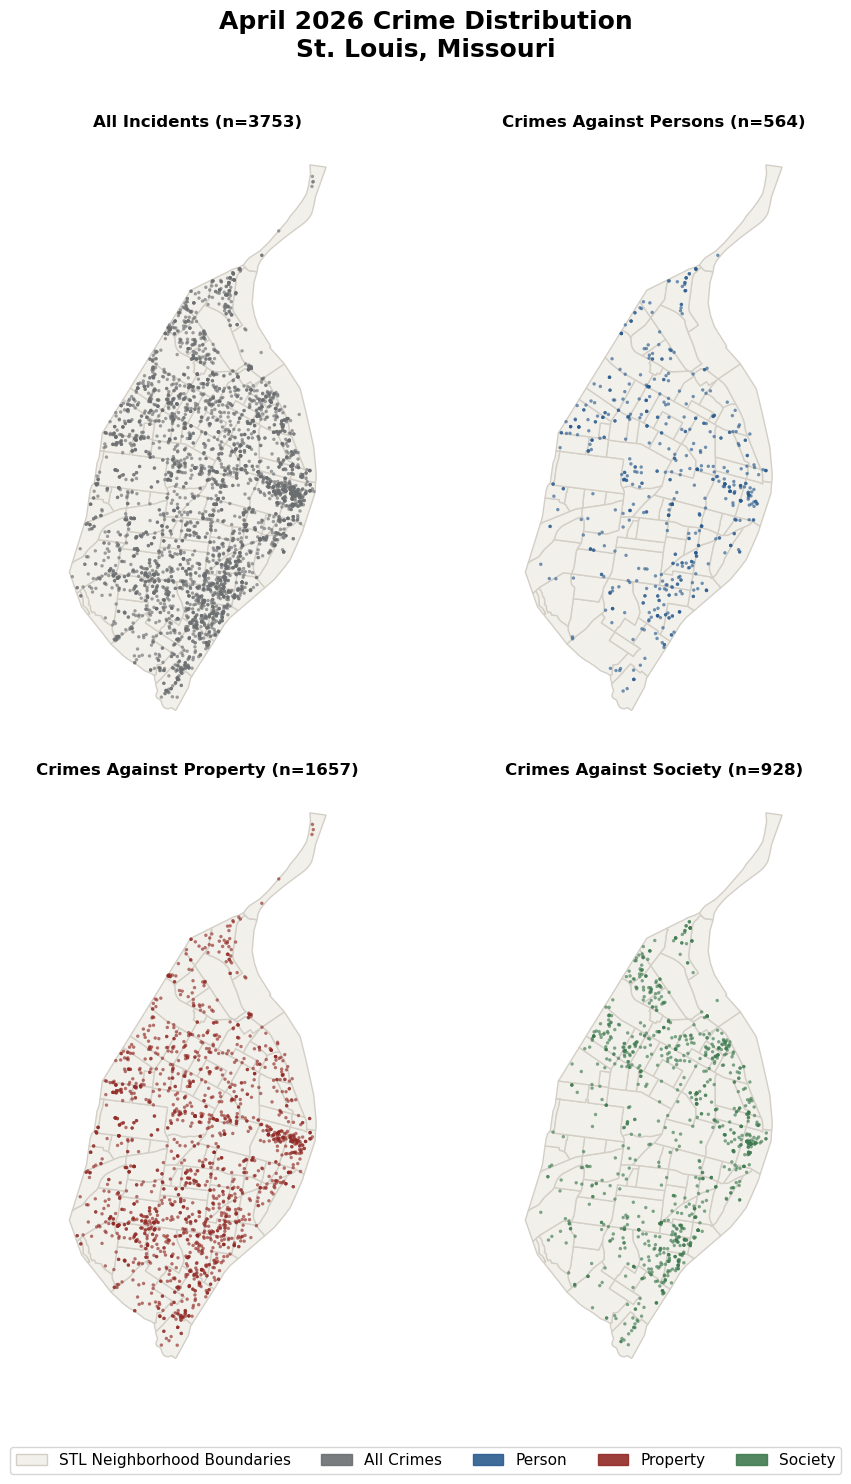

In [5]:
gc.plot_monthly_maps(data_pkg)

### Run the exporters found in utils/export.py

### Create a dedicated test directory to hold output files

In [6]:
TEST_DIR = "./test_exports"
os.makedirs(TEST_DIR, exist_ok=True)

print(f"✅ Ready to test. Output directory created at: {TEST_DIR}")

✅ Ready to test. Output directory created at: ./test_exports


### Export the dataframe to a CSV, a GeoJSON and a GPKG (QGIS)

In [7]:
print("🚀 Executing file export tests...")

# Test Flat CSV Export
csv_success = gc.export_to_csv(data_pkg, output_dir=TEST_DIR)
print(f"  - CSV Export:      {'SUCCESS  💾' if csv_success else 'FAILED ❌'}")

# Test GeoJSON Export (Triggers on-the-fly spatial reconstruction)
geojson_success = gc.export_to_geojson(data_pkg, output_dir=TEST_DIR)
print(f"  - GeoJSON Export:  {'SUCCESS  🌍' if geojson_success else 'FAILED ❌'}")

# Test GeoPackage Export (Triggers spatial reconstruction + SQLite Layer storage)
gpkg_success = gc.export_to_gpkg(data_pkg, output_dir=TEST_DIR)
print(f"  - GeoPackage Export:{'SUCCESS  📦' if gpkg_success else 'FAILED ❌'}")

🚀 Executing file export tests...
  - CSV Export:      SUCCESS  💾
  - GeoJSON Export:  SUCCESS  🌍
  - GeoPackage Export:SUCCESS  📦


### All Done....

### You have pulled a month's worth of crime data from SLMPD, ran it through an ETL, summarized the data and exported it to GIS-ready formats!